# 20. Unsupervised Learning I: Dimensionality Reduction
@Shengli (Bruce) Jiang, University of South Carolina

## What We Covered in the Last Lecture

Neural networks learn a mapping from inputs to known targets.

We discussed:

- epochs and batches
- learning rate and optimizers
- training curves and overfitting
- regularization

Today we remove the target labels and ask what structure is already present in the data.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain what makes a learning problem unsupervised.
2. Apply PCA to high-dimensional chemical measurements.
3. Explain why feature scaling matters for PCA.
4. Use explained variance, loadings, and reconstruction error to interpret PCA.
5. Recognize when linear PCA misses nonlinear structure.
6. Use kernel PCA for nonlinear representations.

## Running the Notebook

Run the cells from top to bottom.

- The wine dataset is included with scikit-learn.
- The process, liquid-crystal, and spectroscopy examples are generated locally.
- No internet connection is required.
- Random seed 26 is used throughout for reproducibility.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.decomposition import KernelPCA, PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(26)

## 1. Unsupervised Learning Means We Fit on X

The scikit-learn wine dataset contains 178 samples and 13 chemical measurements.

It also contains a class label for each sample. We will **not** give those labels to PCA. We keep them only so we can color the final projection and see whether PCA found useful structure on its own.

In [2]:
wine = load_wine(as_frame=True)

X_wine = wine.data.copy()
y_hidden = wine.target.to_numpy()

print("Samples:", X_wine.shape[0])
print("Chemical measurements:", X_wine.shape[1])
print()
display(X_wine.head())

Samples: 178
Chemical measurements: 13



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


The fitting step will use only `X_wine`.

That is the key distinction:

- supervised learning: fit a relationship between `X` and `y`
- unsupervised learning: fit structure using `X` alone

## 2. Why Scaling Matters Before PCA

PCA searches for directions with large variance.

The wine measurements use very different numerical scales. For example, `proline` is measured on a much larger numerical scale than several concentration-like variables.

We compare PCA before and after standardization.

In [3]:
pca_raw = PCA(n_components=2)
pca_raw.fit(X_wine)

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

pca_scaled = PCA(n_components=2)
pca_scaled.fit(X_wine_scaled)

raw_loading = pd.Series(
    np.abs(pca_raw.components_[0]),
    index=X_wine.columns,
    name="Abs raw PC1 loading"
)

scaled_loading = pd.Series(
    np.abs(pca_scaled.components_[0]),
    index=X_wine.columns,
    name="Abs scaled PC1 loading"
)

loading_comparison = pd.concat(
    [raw_loading, scaled_loading],
    axis=1
)

display(
    loading_comparison
    .sort_values("Abs raw PC1 loading", ascending=False)
    .round(3)
)

print(
    "Raw PC1 explained variance:",
    round(pca_raw.explained_variance_ratio_[0], 4)
)
print(
    "Scaled PC1 explained variance:",
    round(pca_scaled.explained_variance_ratio_[0], 4)
)

,Abs raw PC1 loading,Abs scaled PC1 loading
proline,1.000,0.287
magnesium,0.018,0.142
alcalinity_of_ash,0.005,0.239
color_intensity,0.002,0.089
alcohol,0.002,0.144
flavanoids,0.002,0.423
total_phenols,0.001,0.395
od280/od315_of_diluted_wines,0.001,0.376
malic_acid,0.001,0.245
proanthocyanins,0.001,0.313


Raw PC1 explained variance: 0.9981
Scaled PC1 explained variance: 0.362


Without scaling, one large-scale variable can dominate the covariance matrix.

A very large explained-variance ratio is not automatically a good result. It may simply mean one feature uses much larger numerical units.

`StandardScaler` gives each feature zero mean and unit variance before PCA.

## 3. PCA of Chemical Measurements

Now reduce the 13 standardized chemical measurements to two principal components.

The hidden class labels are used only **after** PCA is fitted.

Variance explained by PC1 and PC2: 0.554


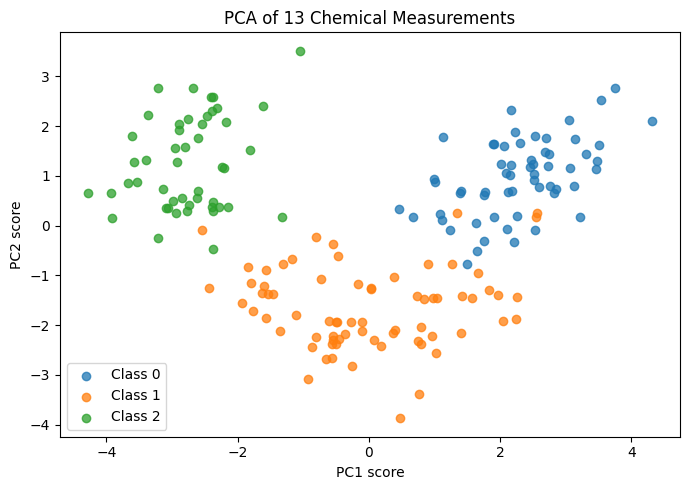

In [4]:
pca_wine = PCA(n_components=2)
wine_scores = pca_wine.fit_transform(X_wine_scaled)

print(
    "Variance explained by PC1 and PC2:",
    round(pca_wine.explained_variance_ratio_.sum(), 3)
)

fig, ax = plt.subplots(figsize=(7, 5))

for class_id in np.unique(y_hidden):
    mask = y_hidden == class_id
    ax.scatter(
        wine_scores[mask, 0],
        wine_scores[mask, 1],
        label=f"Class {class_id}",
        alpha=0.75
    )

ax.set(
    xlabel="PC1 score",
    ylabel="PC2 score",
    title="PCA of 13 Chemical Measurements"
)
ax.legend()

fig.tight_layout()
plt.show()

The class labels were not used to construct PC1 or PC2.

If labeled groups occupy different regions afterward, PCA has exposed structure that was already present in the chemical measurements. That does **not** make PCA a classifier.

## 4. What Does PCA Calculate Under the Hood?

For centered data, PCA finds eigenvectors of the covariance matrix.

The eigenvalues tell us how much variance lies along each principal direction.

In [5]:
covariance = np.cov(X_wine_scaled, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

manual_ratio = eigenvalues / eigenvalues.sum()

comparison = pd.DataFrame({
    "Component": np.arange(1, 6),
    "From covariance": manual_ratio[:5],
    "From sklearn": PCA().fit(X_wine_scaled).explained_variance_ratio_[:5]
})

display(comparison.round(4))

,Component,From covariance,From sklearn
0,1,0.3620,0.3620
1,2,0.1921,0.1921
2,3,0.1112,0.1112
3,4,0.0707,0.0707
4,5,0.0656,0.0656


The two calculations agree.

The sign of an eigenvector is arbitrary. Flipping a principal component from positive to negative does not change the PCA solution.

## 5. How Many Principal Components Should We Keep?

A two-dimensional plot is convenient, but two components may not preserve enough information for another task.

We examine cumulative explained variance across all 13 components.

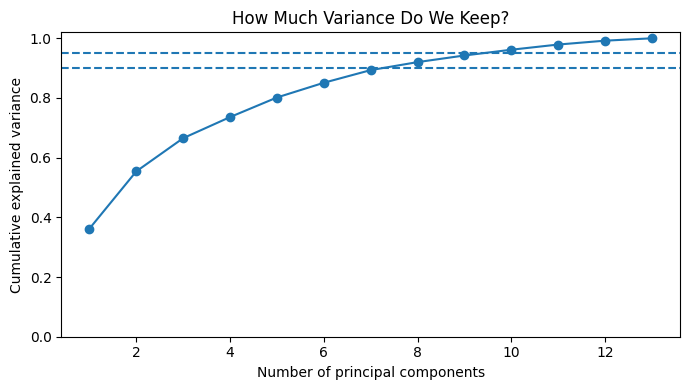

Components for at least 90% variance: 8
Components for at least 95% variance: 10


In [6]:
pca_all = PCA()
pca_all.fit(X_wine_scaled)

cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
components = np.arange(1, len(cumulative_variance) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(components, cumulative_variance, marker="o")
ax.axhline(0.90, linestyle="--")
ax.axhline(0.95, linestyle="--")
ax.set(
    xlabel="Number of principal components",
    ylabel="Cumulative explained variance",
    title="How Much Variance Do We Keep?"
)
ax.set_ylim(0, 1.02)

fig.tight_layout()
plt.show()

n90 = np.argmax(cumulative_variance >= 0.90) + 1
n95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for at least 90% variance:", n90)
print("Components for at least 95% variance:", n95)

Explained variance measures preserved variation in `X`.

It does **not** guarantee that a retained direction is chemically important for every future question.

## 6. Compression and Reconstruction

PCA can project a sample into a smaller space and approximately reconstruct the original standardized features.

More retained components give lower reconstruction error.

In [7]:
rows = []

for n_components in [1, 2, 5, 8, 13]:
    model = PCA(n_components=n_components)
    scores = model.fit_transform(X_wine_scaled)
    reconstructed = model.inverse_transform(scores)

    rmse = np.sqrt(np.mean((X_wine_scaled - reconstructed) ** 2))

    rows.append({
        "Components": n_components,
        "Variance kept": model.explained_variance_ratio_.sum(),
        "Reconstruction RMSE": rmse
    })

reconstruction_table = pd.DataFrame(rows)
display(reconstruction_table.round(3))

,Components,Variance kept,Reconstruction RMSE
0,1,0.362,0.799
1,2,0.554,0.668
2,5,0.802,0.445
3,8,0.920,0.283
4,13,1.000,0.000


The tradeoff is explicit:

- fewer components give stronger compression
- more components preserve more of the original feature space

With all 13 components, PCA is only a rotation of the standardized coordinate system and reconstruction is essentially exact.

## 7. Nonlinear Structure: Liquid-Crystal Orientation Descriptors

For a simple two-dimensional nematic descriptor, write

$$
q_1 = S\cos(2\theta), \qquad
q_2 = S\sin(2\theta),
$$

where:

- $S$ measures alignment strength
- $\theta$ is the director angle

If the director angle varies, two different values of $S$ form two rings in $(q_1,q_2)$ space.

A linear PCA rotation cannot turn radial separation into a single straight coordinate.

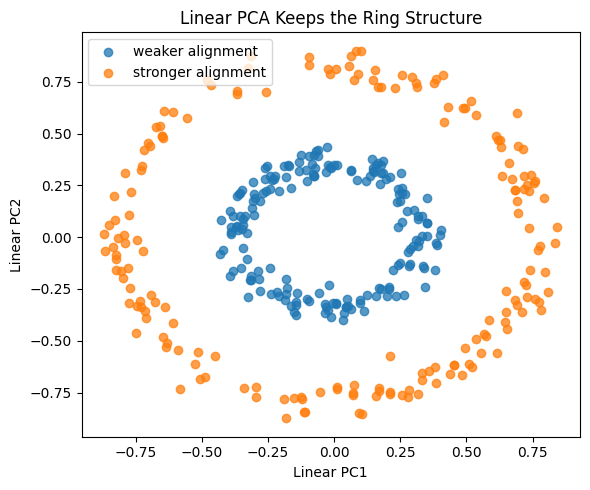

In [10]:
n_each = 180

theta_weak = rng.uniform(0, np.pi, n_each)
theta_strong = rng.uniform(0, np.pi, n_each)

s_weak = rng.normal(0.35, 0.03, n_each)
s_strong = rng.normal(0.80, 0.04, n_each)

q1 = np.concatenate([
    s_weak * np.cos(2 * theta_weak),
    s_strong * np.cos(2 * theta_strong)
])

q2 = np.concatenate([
    s_weak * np.sin(2 * theta_weak),
    s_strong * np.sin(2 * theta_strong)
])

q1 = q1 + rng.normal(0, 0.02, 2 * n_each)
q2 = q2 + rng.normal(0, 0.02, 2 * n_each)

X_lc = np.column_stack([q1, q2])

alignment_state = np.array(
    ["weaker alignment"] * n_each
    + ["stronger alignment"] * n_each
)

linear_scores = PCA(n_components=2).fit_transform(X_lc)

fig, ax = plt.subplots(figsize=(6, 5))

for state in ["weaker alignment", "stronger alignment"]:
    mask = alignment_state == state
    ax.scatter(
        linear_scores[mask, 0],
        linear_scores[mask, 1],
        label=state,
        alpha=0.75
    )

ax.set(
    xlabel="Linear PC1",
    ylabel="Linear PC2",
    title="Linear PCA Keeps the Ring Structure"
)
ax.legend()

fig.tight_layout()
plt.show()

The two alignment strengths are separated by **radius**, not by a straight line.

This is the type of geometry that motivates nonlinear dimensionality reduction.

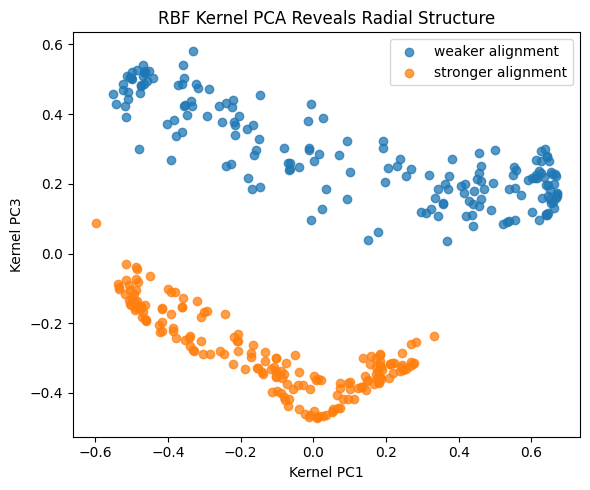

In [11]:
kernel_pca = KernelPCA(
    n_components=3,
    kernel="rbf",
    gamma=5.0,
    random_state=26
)

kernel_scores = kernel_pca.fit_transform(X_lc)

fig, ax = plt.subplots(figsize=(6, 5))

for state in ["weaker alignment", "stronger alignment"]:
    mask = alignment_state == state
    ax.scatter(
        kernel_scores[mask, 0],
        kernel_scores[mask, 2],
        label=state,
        alpha=0.75
    )

ax.set(
    xlabel="Kernel PC1",
    ylabel="Kernel PC3",
    title="RBF Kernel PCA Reveals Radial Structure"
)
ax.legend()

fig.tight_layout()
plt.show()

The RBF kernel creates nonlinear components. Here one of those components becomes strongly sensitive to alignment magnitude.

Two cautions:

- the useful kernel and `gamma` depend on the problem
- kernel components are usually harder to interpret physically than linear PCA loadings